In [11]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install --upgrade pip

!pip -q install \
opencv-python \
opencv-contrib-python \
mediapipe \
networkx \
scikit-image \
scipy \
numpy \
pandas \
matplotlib \
Pillow \
reportlab \
groq \
kaggle \
tqdm \
fpdf

# ============================================================
# UPLOAD KAGGLE API
# ============================================================

from google.colab import files

print("="*60)
print("UPLOAD kaggle.json")
print("="*60)

files.upload()

# ============================================================
# CONFIGURE KAGGLE
# ============================================================

import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move(
    "kaggle.json",
    "/root/.kaggle/kaggle.json"
)

os.chmod(
    "/root/.kaggle/kaggle.json",
    600
)

print("Kaggle Configured Successfully")

# ============================================================
# DOWNLOAD DATASETS
# ============================================================

print("Downloading Palm Dataset...")

!kaggle datasets download \
-d shyambhu/hands-and-palm-images-dataset \
-p /content

print()

print("Downloading Tarot Dataset...")

!kaggle datasets download \
-d lsind18/tarot-json \
-p /content

# ============================================================
# EXTRACT DATASETS
# ============================================================

import zipfile

zip_files = [

    "/content/hands-and-palm-images-dataset.zip",

    "/content/tarot-json.zip"

]

for zip_path in zip_files:

    if os.path.exists(zip_path):

        print("Extracting :", os.path.basename(zip_path))

        with zipfile.ZipFile(zip_path, "r") as zip_ref:

            zip_ref.extractall("/content")

print()

print("Extraction Completed")

# ============================================================
# CREATE PROJECT DIRECTORIES
# ============================================================

folders = [

    "/content/PalmAI",

    "/content/PalmAI/input",

    "/content/PalmAI/output",

    "/content/PalmAI/results",

    "/content/PalmAI/reports",

    "/content/PalmAI/temp"

]

for folder in folders:

    os.makedirs(folder, exist_ok=True)

print("Project Folders Ready")

# ============================================================
# VERIFY DATASETS
# ============================================================

import glob

image_extensions = [

    "*.jpg",

    "*.jpeg",

    "*.png",

    "*.bmp"

]

image_files = []

for ext in image_extensions:

    image_files.extend(

        glob.glob(

            f"/content/**/{ext}",

            recursive=True

        )

    )

print("="*60)

print("Total Images Found :", len(image_files))

csv_files = glob.glob(

    "/content/**/*.csv",

    recursive=True

)

print()

print("CSV Files")

for csv in csv_files:

    print(csv)

json_files = glob.glob(

    "/content/**/*.json",

    recursive=True

)

print()

print("JSON Files")

for file in json_files:

    if "tarot" in file.lower():

        print(file)

print("="*60)

print("Setup Completed Successfully")



UPLOAD kaggle.json


Saving kaggle.json to kaggle.json
Kaggle Configured Successfully
Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
hands-and-palm-images-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)

Dataset URL: https://www.kaggle.com/datasets/lsind18/tarot-json
License(s): other
tarot-json.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting : hands-and-palm-images-dataset.zip
Extracting : tarot-json.zip

Extraction Completed
Project Folders Ready
Total Images Found : 11167

CSV Files
/content/HandInfo.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv

JSON Files
/content/tarot-images.json
Setup Completed Successfully


In [12]:
# ============================================================
# CELL 2
# IMPORTS + MEDIAPIPE TASKS + GROQ + GLOBAL VARIABLES
# ============================================================

import os
import cv2
import json
import math
import glob
import random
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from PIL import Image
from tqdm import tqdm

from scipy import ndimage
from scipy.spatial.distance import euclidean

from skimage.morphology import (
    skeletonize,
    remove_small_objects,
    remove_small_holes
)

from skimage.measure import (
    label,
    regionprops
)

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as PDFImage,
    Table,
    TableStyle
)

from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.lib import colors

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from groq import Groq
from getpass import getpass

warnings.filterwarnings("ignore")

print("="*70)
print("Libraries Imported Successfully")
print("="*70)


# ============================================================
# PROJECT DIRECTORIES
# ============================================================

PROJECT_DIR = "/content/PalmAI"

INPUT_DIR = os.path.join(PROJECT_DIR, "input")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "output")
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")
TEMP_DIR = os.path.join(PROJECT_DIR, "temp")

for folder in [
    PROJECT_DIR,
    INPUT_DIR,
    OUTPUT_DIR,
    RESULT_DIR,
    REPORT_DIR,
    TEMP_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project Directories Ready")


# ============================================================
# DOWNLOAD MEDIAPIPE HAND LANDMARKER MODEL
# ============================================================

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/"
    "hand_landmarker/"
    "float16/1/"
    "hand_landmarker.task"
)

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "hand_landmarker.task"
)

if not os.path.exists(MODEL_PATH):

    print("Downloading MediaPipe Hand Landmarker...")

    urllib.request.urlretrieve(
        MODEL_URL,
        MODEL_PATH
    )

print("Hand Landmarker Model Ready")


# ============================================================
# INITIALIZE MEDIAPIPE
# ============================================================

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.HandLandmarkerOptions(

    base_options=base_options,

    num_hands=1,

    min_hand_detection_confidence=0.5,

    min_hand_presence_confidence=0.5,

    min_tracking_confidence=0.5

)

detector = vision.HandLandmarker.create_from_options(
    options
)

print("MediaPipe Initialized Successfully")


# ============================================================
# GROQ
# ============================================================

MODEL_NAME = "llama-3.3-70b-versatile"

GROQ_API_KEY = getpass("Enter your Groq API Key: ")

client = Groq(
    api_key=GROQ_API_KEY
)

print("Groq Connected Successfully")
print("Model :", MODEL_NAME)


# ============================================================
# TEST GROQ CONNECTION
# ============================================================

try:

    response = client.chat.completions.create(

        model=MODEL_NAME,

        messages=[
            {
                "role": "user",
                "content": "Reply only with Connected."
            }
        ],

        temperature=0

    )

    print("Groq Response :", response.choices[0].message.content)

except Exception as e:

    print("Groq Connection Failed")
    print(e)


# ============================================================
# GLOBAL VARIABLES
# ============================================================

ORIGINAL_IMAGE = None

PALM_IMAGE = None

PALM_ROI = None

PALM_MASK = None

GRAY = None

CLAHE_IMAGE = None

THRESHOLD_IMAGE = None

MORPH_IMAGE = None

SKELETON = None

GRAPH = None

GRAPH_IMAGE = None

EDGE_LIST = []

LIFE_LINE = None

HEAD_LINE = None

HEART_LINE = None

FATE_LINE = None

PALM_FEATURES = {}

TAROT_RESULT = {}

REPORT_PATH = None


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def show(image, title="Image", size=(6, 6), cmap=None):

    plt.figure(figsize=size)

    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()


def save_image(filename, image):

    path = os.path.join(
        RESULT_DIR,
        filename
    )

    cv2.imwrite(path, image)

    return path


print("="*70)
print("CELL 2 COMPLETED SUCCESSFULLY")
print("="*70)


Libraries Imported Successfully
Project Directories Ready
Hand Landmarker Model Ready
MediaPipe Initialized Successfully
Enter your Groq API Key: ··········
Groq Connected Successfully
Model : llama-3.3-70b-versatile
Groq Response : Connected
CELL 2 COMPLETED SUCCESSFULLY


CELL 3 : IMAGE LOADING & HAND DETECTION
Dataset Found : /content/Hands

1 -> Random Dataset Image
2 -> Upload Your Image
Enter Choice : 1

Images Found : 5396

Random Image Selected
/content/Hands/Hands/Hand_0010453.jpg

Image Size : (1200, 1600, 3)


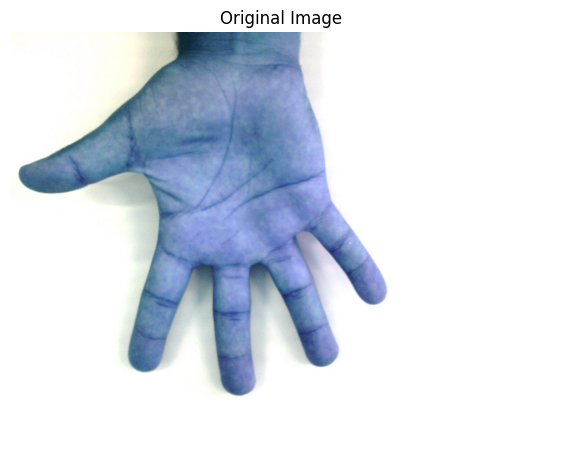


Detected : Right
Landmarks : 21


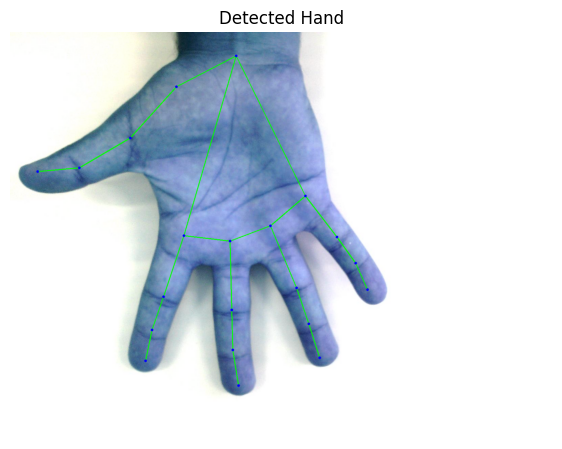


Rotation Angle : 1.89


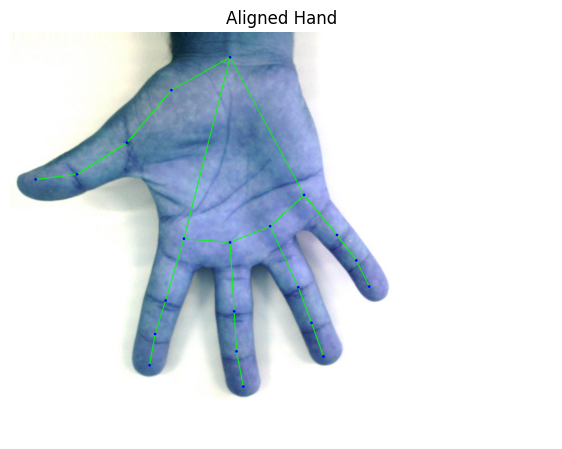


Hand Alignment Completed

ROBUST PALM ROI EXTRACTION

Palm Center : 658 439
Radius : 391

ROI Shape : (700, 700, 3)


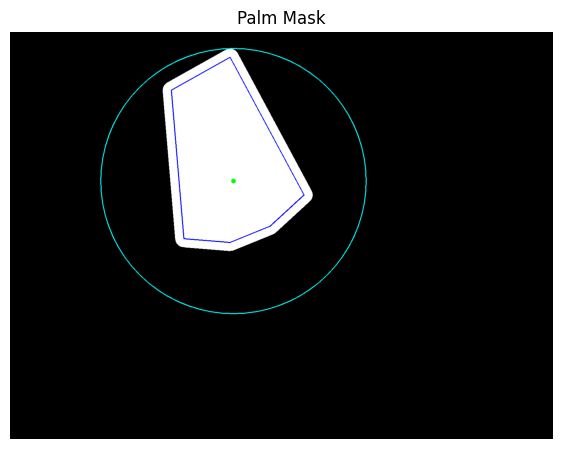

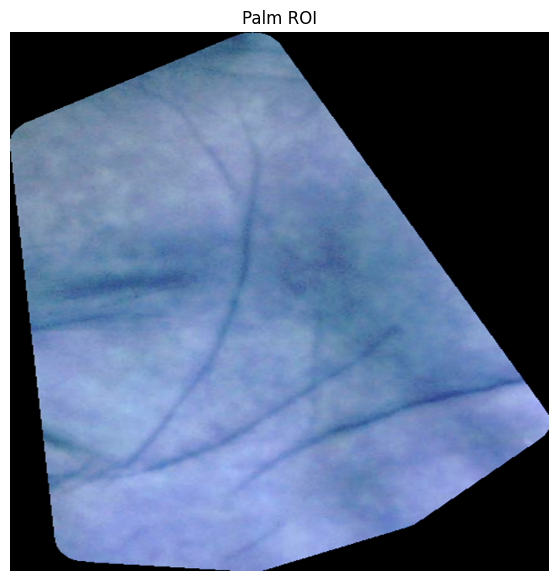

ROI EXTRACTION COMPLETED

FINALIZING CELL 3

Original Image Shape : (1200, 1600, 3)
Aligned Image Shape  : (1200, 1600, 3)
Palm ROI Shape       : (700, 700, 3)

Results Folder
/content/Results


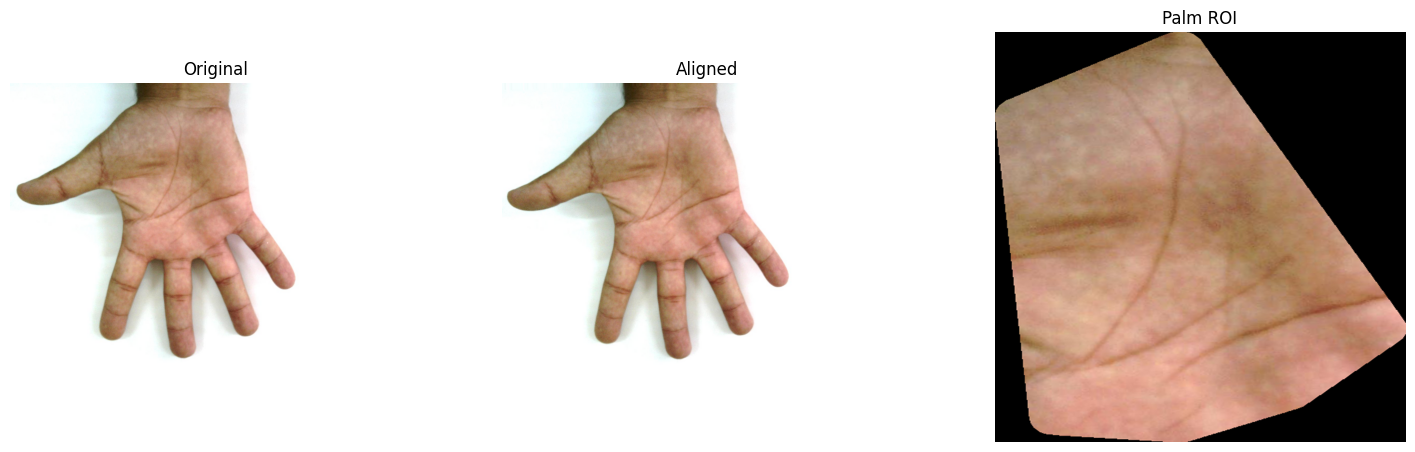


VARIABLE CHECK
ORIGINAL_IMAGE       OK
ROTATED_IMAGE        OK
PALM_ROI             OK
RESULT_DIR           OK
OUTPUT_DIR           OK
REPORT_DIR           OK
HAND_SIDE            OK
image_path           OK

CELL 3 COMPLETED SUCCESSFULLY


In [23]:
# ============================================================
# CELL 3
# PART 1
# IMAGE SELECTION + HAND DETECTION
# ============================================================

print("="*70)
print("CELL 3 : IMAGE LOADING & HAND DETECTION")
print("="*70)

import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Locate Dataset Automatically
# ------------------------------------------------------------

possible_paths = [

    "/content/Hands",
    "/content/hands-and-palm-images-dataset",
    "/content/dataset"

]

HAND_DATASET = None

for p in possible_paths:

    if os.path.exists(p):

        HAND_DATASET = p
        break

if HAND_DATASET is None:

    raise Exception("Hands Dataset Folder Not Found.")

print("Dataset Found :", HAND_DATASET)

# ------------------------------------------------------------
# Image Extensions
# ------------------------------------------------------------

IMAGE_EXTENSIONS = (

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"

)

# ------------------------------------------------------------
# User Choice
# ------------------------------------------------------------

print()

print("1 -> Random Dataset Image")
print("2 -> Upload Your Image")

choice = input("Enter Choice : ")

# ------------------------------------------------------------
# Random Dataset Image
# ------------------------------------------------------------

if choice == "1":

    # Use the pre-filtered list of palmar image names
    image_files_base = palmar_image_names
    image_files = [os.path.join(HAND_DATASET, "Hands", f) for f in image_files_base] # Adjust path if HAND_DATASET is not the parent of 'Hands'

    print()

    print("Images Found :", len(image_files))

    if len(image_files)==0:

        raise Exception("Dataset Contains No Images.")

    image_path = random.choice(image_files)

    print()

    print("Random Image Selected")

    print(image_path)

# ------------------------------------------------------------
# Upload
# ------------------------------------------------------------

else:

    from google.colab import files

    uploaded = files.upload()

    image_path = list(uploaded.keys())[0]

# ------------------------------------------------------------
# Read Image
# ------------------------------------------------------------

bgr = cv2.imread(image_path)

if bgr is None:

    raise Exception("Cannot Read Image")

ORIGINAL_IMAGE = cv2.cvtColor(

    bgr,

    cv2.COLOR_BGR2RGB

)

height,width = ORIGINAL_IMAGE.shape[:2]

print()

print("Image Size :", ORIGINAL_IMAGE.shape)

show(

    ORIGINAL_IMAGE,

    "Original Image",

    (7,7)

)

# ============================================================
# MediaPipe Detection
# ============================================================

mp_image = mp.Image.create_from_file(image_path)

result = detector.detect(mp_image)

if len(result.hand_landmarks)==0:

    raise Exception("No Hand Detected")

hand = result.hand_landmarks[0]

HAND_SIDE = result.handedness[0][0].category_name

print()

print("Detected :", HAND_SIDE)

# ------------------------------------------------------------
# Landmark Pixels
# ------------------------------------------------------------

LANDMARKS = []

for lm in hand:

    x = int(lm.x*width)

    y = int(lm.y*height)

    LANDMARKS.append([x,y])

LANDMARKS = np.array(

    LANDMARKS,

    dtype=np.int32

)

print("Landmarks :", len(LANDMARKS))

# ============================================================
# CELL 3
# PART 2
# DRAW LANDMARKS + HAND ALIGNMENT
# ============================================================

# ------------------------------------------------------------
# Draw Landmarks
# ------------------------------------------------------------

connections = [

    (0,1),(1,2),(2,3),(3,4),

    (0,5),(5,6),(6,7),(7,8),

    (5,9),(9,10),(10,11),(11,12),

    (9,13),(13,14),(14,15),(15,16),

    (13,17),(17,18),(18,19),(19,20),

    (0,17)

]

landmark_img = ORIGINAL_IMAGE.copy()

for s,e in connections:

    cv2.line(

        landmark_img,

        tuple(LANDMARKS[s]),

        tuple(LANDMARKS[e]),

        (0,255,0),

        2

    )

for p in LANDMARKS:

    cv2.circle(

        landmark_img,

        tuple(p),

        4,

        (255,0,0),

        -1

    )

show(

    landmark_img,

    "Detected Hand",

    (7,7)

)

# ------------------------------------------------------------
# Landmark References
# ------------------------------------------------------------

WRIST      = LANDMARKS[0]

THUMB_CMC  = LANDMARKS[1]
THUMB_MCP  = LANDMARKS[2]
THUMB_IP   = LANDMARKS[3]
THUMB_TIP  = LANDMARKS[4]

INDEX_MCP  = LANDMARKS[5]
INDEX_PIP  = LANDMARKS[6]
INDEX_DIP  = LANDMARKS[7]
INDEX_TIP  = LANDMARKS[8]

MIDDLE_MCP = LANDMARKS[9]
MIDDLE_PIP = LANDMARKS[10]
MIDDLE_DIP = LANDMARKS[11]
MIDDLE_TIP = LANDMARKS[12]

RING_MCP   = LANDMARKS[13]
RING_PIP   = LANDMARKS[14]
RING_DIP   = LANDMARKS[15]
RING_TIP   = LANDMARKS[16]

LITTLE_MCP = LANDMARKS[17]
LITTLE_PIP = LANDMARKS[18]
LITTLE_DIP = LANDMARKS[19]
LITTLE_TIP = LANDMARKS[20]

# ------------------------------------------------------------
# Compute Rotation
# ------------------------------------------------------------

dx = MIDDLE_MCP[0] - WRIST[0]
dy = MIDDLE_MCP[1] - WRIST[1]

angle = np.degrees(

    np.arctan2(

        dy,

        dx

    )

)

rotation_angle = angle - 90

print()

print("Rotation Angle :", round(rotation_angle,2))

# ------------------------------------------------------------
# Rotate Image
# ------------------------------------------------------------

center = (

    width//2,

    height//2

)

rotation_matrix = cv2.getRotationMatrix2D(

    center,

    rotation_angle,

    1.0

)

ROTATED_IMAGE = cv2.warpAffine(

    ORIGINAL_IMAGE,

    rotation_matrix,

    (width,height),

    flags=cv2.INTER_CUBIC,

    borderMode=cv2.BORDER_REPLICATE

)

# ------------------------------------------------------------
# Rotate Landmarks
# ------------------------------------------------------------

ROTATED_POINTS = []

for x,y in LANDMARKS:

    rx = rotation_matrix[0,0]*x + rotation_matrix[0,1]*y + rotation_matrix[0,2]

    ry = rotation_matrix[1,0]*x + rotation_matrix[1,1]*y + rotation_matrix[1,2]

    ROTATED_POINTS.append([

        int(rx),

        int(ry)

    ])

ROTATED_POINTS = np.array(

    ROTATED_POINTS,

    dtype=np.int32

)

# ------------------------------------------------------------
# Draw Rotated Landmarks
# ------------------------------------------------------------

rotated_vis = ROTATED_IMAGE.copy()

for s,e in connections:

    cv2.line(

        rotated_vis,

        tuple(ROTATED_POINTS[s]),

        tuple(ROTATED_POINTS[e]),

        (0,255,0),

        2

    )

for p in ROTATED_POINTS:

    cv2.circle(

        rotated_vis,

        tuple(p),

        4,

        (255,0,0),

        -1

    )

show(

    rotated_vis,

    "Aligned Hand",

    (7,7)

)

# ------------------------------------------------------------
# Update Landmark Variables
# ------------------------------------------------------------

WRIST      = ROTATED_POINTS[0]

THUMB_CMC  = ROTATED_POINTS[1]
THUMB_MCP  = ROTATED_POINTS[2]
THUMB_IP   = ROTATED_POINTS[3]
THUMB_TIP  = ROTATED_POINTS[4]

INDEX_MCP  = ROTATED_POINTS[5]
INDEX_PIP  = ROTATED_POINTS[6]
INDEX_DIP  = ROTATED_POINTS[7]
INDEX_TIP  = ROTATED_POINTS[8]

MIDDLE_MCP = ROTATED_POINTS[9]
MIDDLE_PIP = ROTATED_POINTS[10]
MIDDLE_DIP = ROTATED_POINTS[11]
MIDDLE_TIP = ROTATED_POINTS[12]

RING_MCP   = ROTATED_POINTS[13]
RING_PIP   = ROTATED_POINTS[14]
RING_DIP   = ROTATED_POINTS[15]
RING_TIP   = ROTATED_POINTS[16]

LITTLE_MCP = ROTATED_POINTS[17]
LITTLE_PIP = ROTATED_POINTS[18]
LITTLE_DIP = ROTATED_POINTS[19]
LITTLE_TIP = ROTATED_POINTS[20]

print()

print("Hand Alignment Completed")
print("="*70)

# ============================================================
# CELL 3
# PART 3
# ROBUST PALM ROI EXTRACTION
# ============================================================

print()
print("="*70)
print("ROBUST PALM ROI EXTRACTION")
print("="*70)

# ------------------------------------------------------------
# Palm Landmarks
# ------------------------------------------------------------

palm_points = np.array([

    WRIST,
    THUMB_CMC,
    INDEX_MCP,
    MIDDLE_MCP,
    RING_MCP,
    LITTLE_MCP

], dtype=np.int32)

# ------------------------------------------------------------
# Convex Hull
# ------------------------------------------------------------

hull = cv2.convexHull(palm_points)

mask = np.zeros(

    (height, width),

    dtype=np.uint8

)

cv2.fillConvexPoly(

    mask,

    hull,

    255

)

# ------------------------------------------------------------
# Dilate Hull
# ------------------------------------------------------------

kernel = cv2.getStructuringElement(

    cv2.MORPH_ELLIPSE,

    (51,51)

)

mask = cv2.dilate(

    mask,

    kernel,

    iterations=1

)

# ------------------------------------------------------------
# Keep Largest Component
# ------------------------------------------------------------

numLabels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

largest = np.zeros_like(mask)

if numLabels > 1:

    idx = 1 + np.argmax(

        stats[1:, cv2.CC_STAT_AREA]

    )

    largest[labels==idx] = 255

mask = largest

# ------------------------------------------------------------
# Palm Center
# ------------------------------------------------------------

dist = cv2.distanceTransform(

    mask,

    cv2.DIST_L2,

    5

)

_, radius, _, center = cv2.minMaxLoc(dist)

cx, cy = center

radius = int(radius*2.1)

print()

print("Palm Center :",cx,cy)

print("Radius :",radius)

# ------------------------------------------------------------
# Adaptive Crop
# ------------------------------------------------------------

xmin = max(0, cx-radius)

xmax = min(width, cx+radius)

ymin = max(0, cy-radius)

ymax = min(height, cy+radius)

PALM_ROI = ROTATED_IMAGE[

    ymin:ymax,

    xmin:xmax

].copy()

# ------------------------------------------------------------
# Empty Check
# ------------------------------------------------------------

if PALM_ROI.size == 0:

    raise Exception(

        "Palm ROI Extraction Failed"

    )

# ------------------------------------------------------------
# Palm Mask inside ROI
# ------------------------------------------------------------

roi_mask = mask[

    ymin:ymax,

    xmin:xmax

]

PALM_ROI = cv2.bitwise_and(

    PALM_ROI,

    PALM_ROI,

    mask=roi_mask

)

# ------------------------------------------------------------
# Remove Black Border
# ------------------------------------------------------------

gray = cv2.cvtColor(

    PALM_ROI,

    cv2.COLOR_RGB2GRAY

)

ys, xs = np.where(gray > 5)

if len(xs):

    x1 = np.min(xs)
    x2 = np.max(xs)

    y1 = np.min(ys)
    y2 = np.max(ys)

    PALM_ROI = PALM_ROI[

        y1:y2,

        x1:x2

    ]

# ------------------------------------------------------------
# Resize
# ------------------------------------------------------------

PALM_ROI = cv2.resize(

    PALM_ROI,

    (700,700),

    interpolation=cv2.INTER_CUBIC

)

print()

print("ROI Shape :",PALM_ROI.shape)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

mask_vis = cv2.cvtColor(

    mask,

    cv2.COLOR_GRAY2RGB

)

cv2.drawContours(

    mask_vis,

    [hull],

    -1,

    (255,0,0),

    2

)

cv2.circle(

    mask_vis,

    (cx,cy),

    7,

    (0,255,0),

    -1

)

cv2.circle(

    mask_vis,

    (cx,cy),

    radius,

    (255,255,0),

    2

)

show(

    mask_vis,

    "Palm Mask",

    (7,7)

)

show(

    PALM_ROI,

    "Palm ROI",

    (7,7)

)

print("="*70)
print("ROI EXTRACTION COMPLETED")
print("="*70)
# ============================================================
# CELL 3
# PART 4
# SAVE OUTPUTS & FINALIZE
# ============================================================

print()
print("="*70)
print("FINALIZING CELL 3")
print("="*70)

# ------------------------------------------------------------
# Create Output Directories
# ------------------------------------------------------------

PROJECT_DIR = "/content"

RESULT_DIR = os.path.join(
    PROJECT_DIR,
    "Results"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "Output"
)

REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "Reports"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    REPORT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Save Images
# ------------------------------------------------------------

cv2.imwrite(

    os.path.join(
        RESULT_DIR,
        "Original_Image.png"
    ),

    cv2.cvtColor(
        ORIGINAL_IMAGE,
        cv2.COLOR_RGB2BGR
    )

)

cv2.imwrite(

    os.path.join(
        RESULT_DIR,
        "Aligned_Hand.png"
    ),

    cv2.cvtColor(
        ROTATED_IMAGE,
        cv2.COLOR_RGB2BGR
    )

)

cv2.imwrite(

    os.path.join(
        RESULT_DIR,
        "Palm_ROI.png"
    ),

    cv2.cvtColor(
        PALM_ROI,
        cv2.COLOR_RGB2BGR
    )

)

cv2.imwrite(

    os.path.join(
        RESULT_DIR,
        "Palm_Mask.png"
    ),

    mask

)

# ------------------------------------------------------------
# Information
# ------------------------------------------------------------

print()

print("Original Image Shape :",
      ORIGINAL_IMAGE.shape)

print("Aligned Image Shape  :",
      ROTATED_IMAGE.shape)

print("Palm ROI Shape       :",
      PALM_ROI.shape)

print()

print("Results Folder")

print(RESULT_DIR)

# ------------------------------------------------------------
# Display Final Images
# ------------------------------------------------------------

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(ORIGINAL_IMAGE)
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(ROTATED_IMAGE)
plt.title("Aligned")
plt.axis("off")

plt.subplot(133)
plt.imshow(PALM_ROI)
plt.title("Palm ROI")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# Verify Variables Required By Remaining Cells
# ------------------------------------------------------------

required = [

    "ORIGINAL_IMAGE",
    "ROTATED_IMAGE",
    "PALM_ROI",
    "RESULT_DIR",
    "OUTPUT_DIR",
    "REPORT_DIR",
    "HAND_SIDE",
    "image_path"

]

print()
print("="*70)
print("VARIABLE CHECK")
print("="*70)

for var in required:

    if var in globals():

        print(f"{var:<20} OK")

    else:

        print(f"{var:<20} MISSING")

print()

print("="*70)
print("CELL 3 COMPLETED SUCCESSFULLY")
print("="*70)

In [20]:
import pandas as pd

hand_info_df = pd.read_csv('/content/HandInfo.csv')
display(hand_info_df.head())

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [21]:
print(hand_info_df['aspectOfHand'].unique())

['dorsal right' 'dorsal left' 'palmar left' 'palmar right']


In [22]:
palmar_hands_df = hand_info_df[hand_info_df['aspectOfHand'].isin(['palmar left', 'palmar right'])]
palmar_image_names = palmar_hands_df['imageName'].tolist()
print(f"Found {len(palmar_image_names)} palmar hand images.")
print("First 10 palmar image names:")
for name in palmar_image_names[:10]:
    print(name)

Found 5396 palmar hand images.
First 10 palmar image names:
Hand_0000038.jpg
Hand_0000039.jpg
Hand_0000040.jpg
Hand_0000041.jpg
Hand_0000042.jpg
Hand_0000043.jpg
Hand_0000044.jpg
Hand_0000045.jpg
Hand_0000046.jpg
Hand_0000047.jpg


ADVANCED PALM PREPROCESSING


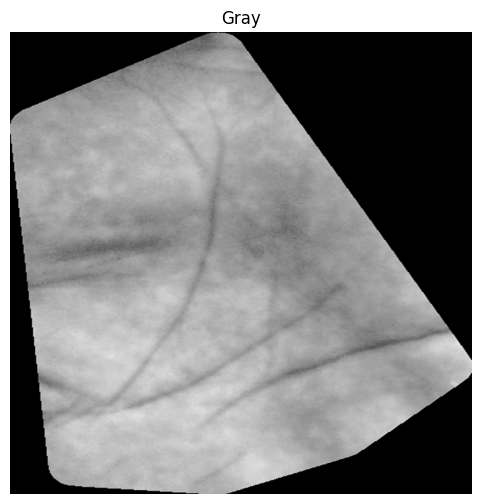

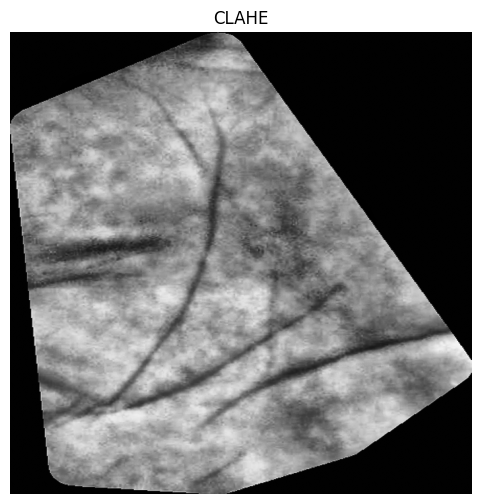

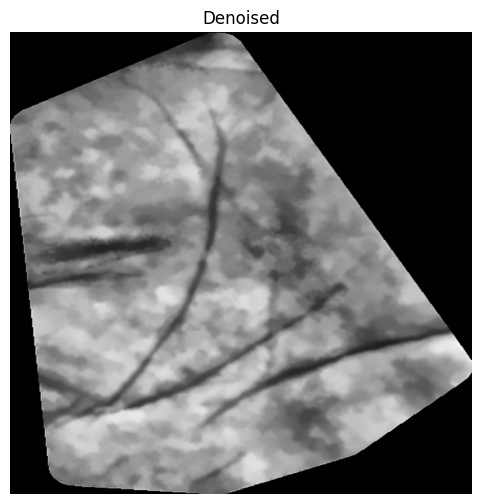

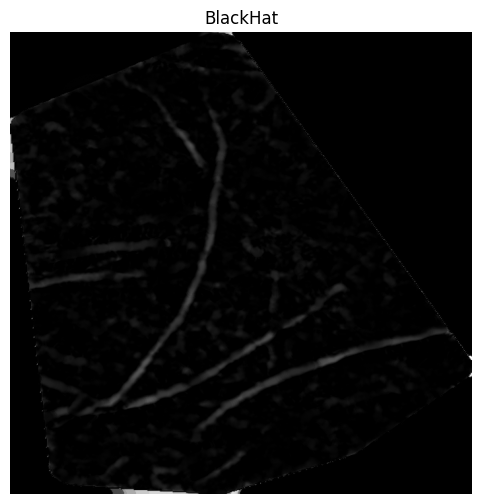

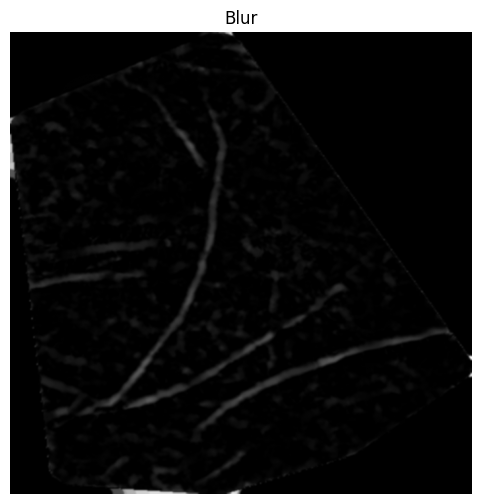

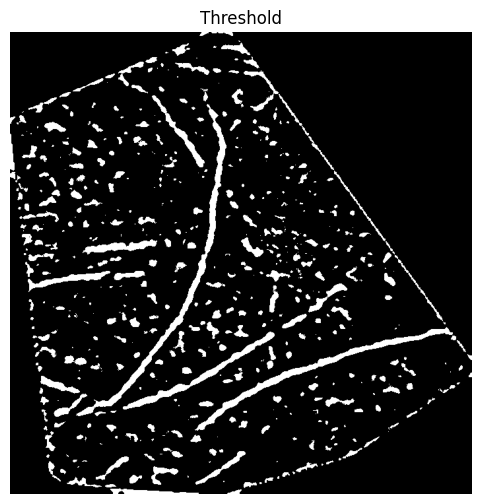

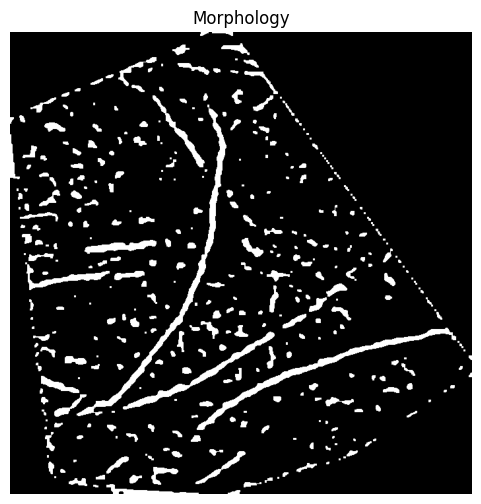

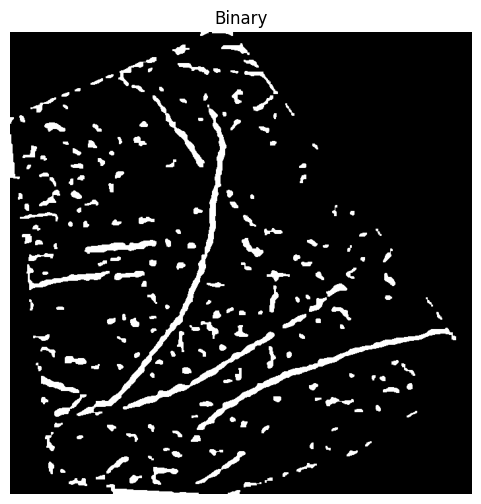

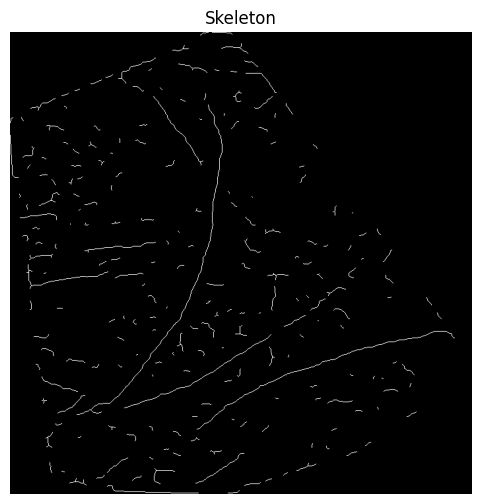

PREPROCESSING COMPLETED


In [24]:
# ============================================================
# CELL 4
# ADVANCED PREPROCESSING
# ============================================================

print("="*70)
print("ADVANCED PALM PREPROCESSING")
print("="*70)

# ------------------------------------------------------------
# RGB -> GRAY
# ------------------------------------------------------------

GRAY = cv2.cvtColor(
    PALM_ROI,
    cv2.COLOR_BGR2GRAY
)

show(
    GRAY,
    "Gray",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# CLAHE
# ------------------------------------------------------------

clahe = cv2.createCLAHE(
    clipLimit=3.5,
    tileGridSize=(8,8)
)

CLAHE = clahe.apply(GRAY)

show(
    CLAHE,
    "CLAHE",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# DENOISE
# ------------------------------------------------------------

DENOISED = cv2.fastNlMeansDenoising(

    CLAHE,

    None,

    12,

    7,

    21

)

show(
    DENOISED,
    "Denoised",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# BLACKHAT
# ------------------------------------------------------------

kernel = cv2.getStructuringElement(

    cv2.MORPH_ELLIPSE,

    (17,17)

)

BLACKHAT = cv2.morphologyEx(

    DENOISED,

    cv2.MORPH_BLACKHAT,

    kernel

)

show(
    BLACKHAT,
    "BlackHat",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# GAUSSIAN
# ------------------------------------------------------------

BLUR = cv2.GaussianBlur(

    BLACKHAT,

    (5,5),

    0

)

show(
    BLUR,
    "Blur",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# ADAPTIVE THRESHOLD
# ------------------------------------------------------------

THRESHOLD = cv2.adaptiveThreshold(

    BLUR,

    255,

    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,

    cv2.THRESH_BINARY,

    31,

    -3

)

show(
    THRESHOLD,
    "Threshold",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# MORPH OPEN
# ------------------------------------------------------------

kernel = np.ones((3,3),np.uint8)

OPEN = cv2.morphologyEx(

    THRESHOLD,

    cv2.MORPH_OPEN,

    kernel,

    iterations=1

)

# ------------------------------------------------------------
# MORPH CLOSE
# ------------------------------------------------------------

CLOSE = cv2.morphologyEx(

    OPEN,

    cv2.MORPH_CLOSE,

    kernel,

    iterations=2

)

show(
    CLOSE,
    "Morphology",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# REMOVE SMALL OBJECTS
# ------------------------------------------------------------

binary = CLOSE > 0

binary = remove_small_objects(

    binary,

    min_size=35

)

binary = remove_small_holes(

    binary,

    area_threshold=35

)

binary = binary.astype(np.uint8)*255

show(
    binary,
    "Binary",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# SKELETON
# ------------------------------------------------------------

SKELETON = skeletonize(binary > 0)

SKELETON = (
    SKELETON.astype(np.uint8)
)*255

show(
    SKELETON,
    "Skeleton",
    (6,6),
    cmap="gray"
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

save_image("01_gray.png",GRAY)
save_image("02_clahe.png",CLAHE)
save_image("03_denoised.png",DENOISED)
save_image("04_blackhat.png",BLACKHAT)
save_image("05_threshold.png",THRESHOLD)
save_image("06_binary.png",binary)
save_image("07_skeleton.png",SKELETON)

print("="*70)
print("PREPROCESSING COMPLETED")
print("="*70)

GRAPH CONSTRUCTION
Endpoints : 477
Junctions : 135


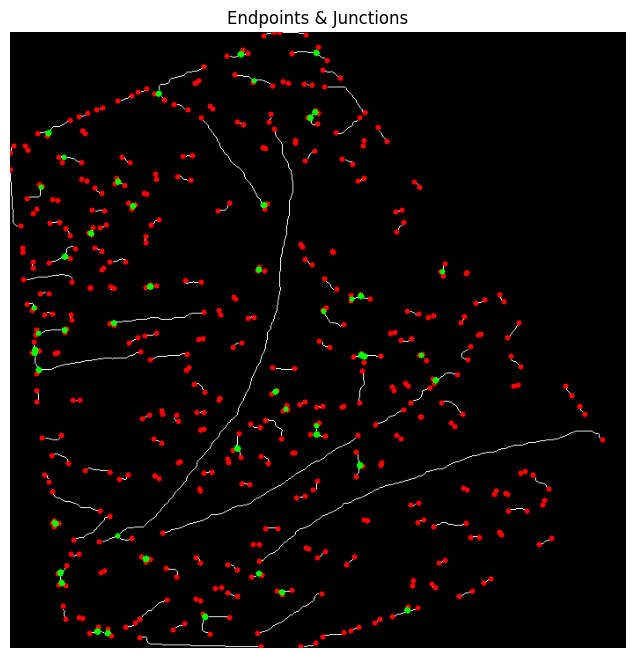


Graph Built
Nodes : 612
Edges : 447


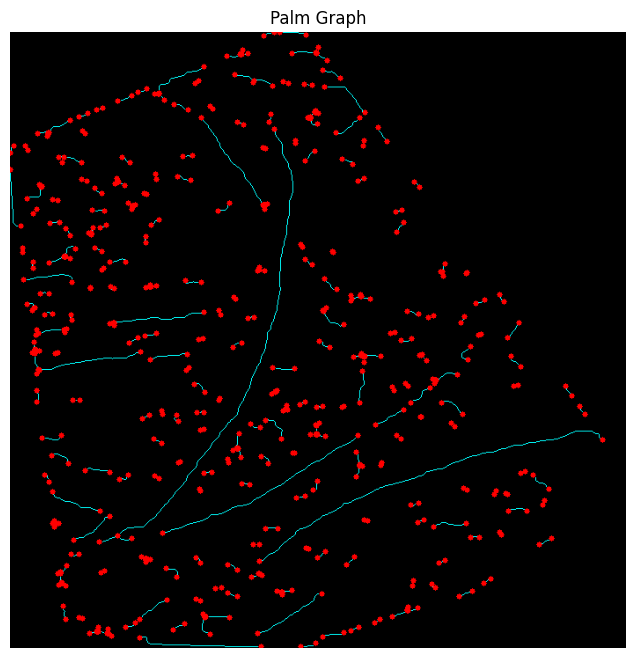

GRAPH CONSTRUCTION COMPLETED


In [25]:
# ============================================================
# CELL 5
# GRAPH CONSTRUCTION FROM PALM SKELETON
# ============================================================

print("="*70)
print("GRAPH CONSTRUCTION")
print("="*70)

import networkx as nx

# ------------------------------------------------------------
# Binary Skeleton
# ------------------------------------------------------------

skel = (SKELETON > 0).astype(np.uint8)

height, width = skel.shape

# ------------------------------------------------------------
# 8-Neighbour Directions
# ------------------------------------------------------------

directions = [

    (-1,-1),
    (-1,0),
    (-1,1),

    (0,-1),
    (0,1),

    (1,-1),
    (1,0),
    (1,1)

]

# ------------------------------------------------------------
# Neighbour Counter
# ------------------------------------------------------------

def neighbours(y,x):

    pts=[]

    for dy,dx in directions:

        ny=y+dy
        nx=x+dx

        if 0<=ny<height and 0<=nx<width:

            if skel[ny,nx]:

                pts.append((ny,nx))

    return pts

# ------------------------------------------------------------
# Endpoints and Junctions
# ------------------------------------------------------------

endpoints=[]

junctions=[]

for y in range(height):

    for x in range(width):

        if skel[y,x]:

            n=len(neighbours(y,x))

            if n==1:

                endpoints.append((y,x))

            elif n>=3:

                junctions.append((y,x))

print("Endpoints :",len(endpoints))
print("Junctions :",len(junctions))

# ------------------------------------------------------------
# Draw Nodes
# ------------------------------------------------------------

node_image=cv2.cvtColor(
    SKELETON,
    cv2.COLOR_GRAY2BGR
)

for y,x in endpoints:

    cv2.circle(

        node_image,

        (x,y),

        3,

        (0,0,255),

        -1

    )

for y,x in junctions:

    cv2.circle(

        node_image,

        (x,y),

        3,

        (0,255,0),

        -1

    )

show(
    node_image,
    "Endpoints & Junctions",
    (8,8)
)

# ------------------------------------------------------------
# Important Nodes
# ------------------------------------------------------------

important_nodes=set(endpoints+junctions)

# ------------------------------------------------------------
# Graph
# ------------------------------------------------------------

GRAPH=nx.Graph()

visited=set()

# ------------------------------------------------------------
# Trace Edge
# ------------------------------------------------------------

def trace_edge(start,next_pixel):

    edge=[]

    previous=start

    current=next_pixel

    edge.append(start)

    while True:

        edge.append(current)

        if current in important_nodes:

            break

        nbrs=neighbours(current[0],current[1])

        nbrs=[p for p in nbrs if p!=previous]

        if len(nbrs)==0:

            break

        previous=current

        current=nbrs[0]

    return edge

# ------------------------------------------------------------
# Build Graph
# ------------------------------------------------------------

for node in important_nodes:

    for nxt in neighbours(node[0],node[1]):

        key=tuple(sorted([node,nxt]))

        if key in visited:

            continue

        edge=trace_edge(node,nxt)

        if len(edge)<2:

            continue

        start=edge[0]

        end=edge[-1]

        visited.add(key)

        GRAPH.add_node(start)

        GRAPH.add_node(end)

        GRAPH.add_edge(

            start,

            end,

            pixels=edge,

            length=len(edge)

        )

print()

print("Graph Built")

print("Nodes :",GRAPH.number_of_nodes())

print("Edges :",GRAPH.number_of_edges())

# ------------------------------------------------------------
# Draw Graph
# ------------------------------------------------------------

graph_img=cv2.cvtColor(
    SKELETON,
    cv2.COLOR_GRAY2BGR
)

for u,v,data in GRAPH.edges(data=True):

    pts=data["pixels"]

    for p1,p2 in zip(pts[:-1],pts[1:]):

        cv2.line(

            graph_img,

            (p1[1],p1[0]),

            (p2[1],p2[0]),

            (255,255,0),

            1

        )

for node in GRAPH.nodes():

    cv2.circle(

        graph_img,

        (node[1],node[0]),

        3,

        (0,0,255),

        -1

    )

show(
    graph_img,
    "Palm Graph",
    (8,8)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

GRAPH_IMAGE=graph_img.copy()

save_image(
    "08_graph.png",
    GRAPH_IMAGE
)

print("="*70)
print("GRAPH CONSTRUCTION COMPLETED")
print("="*70)

PALM LINE DETECTION
Candidate Edges : 52


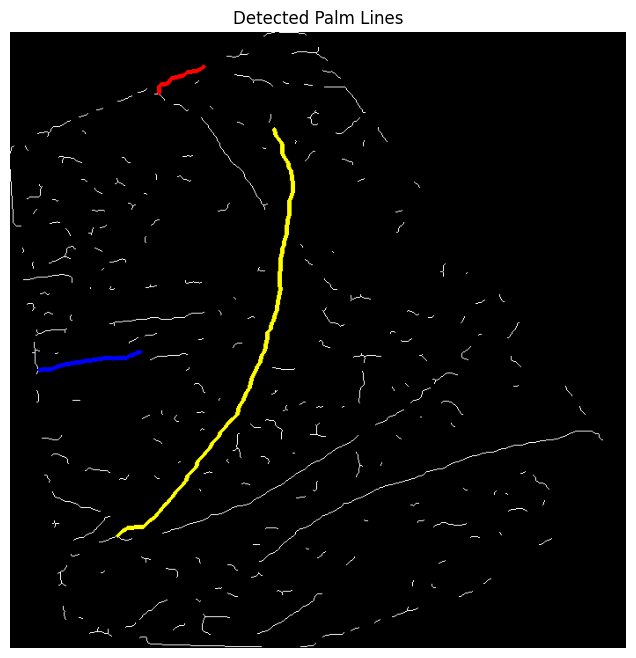

LINE DETECTION COMPLETED


In [26]:
# ============================================================
# CELL 6
# DETECT LIFE, HEAD, HEART & FATE LINES
# ============================================================

print("="*70)
print("PALM LINE DETECTION")
print("="*70)

from math import atan2,degrees

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def edge_angle(edge):

    pts=edge["pixels"]

    p1=pts[0]
    p2=pts[-1]

    dy=p2[0]-p1[0]
    dx=p2[1]-p1[1]

    return abs(degrees(atan2(dy,dx)))

def edge_center(edge):

    pts=np.array(edge["pixels"])

    return pts.mean(axis=0)

# ------------------------------------------------------------
# Collect Graph Edges
# ------------------------------------------------------------

edges=[]

for u,v,data in GRAPH.edges(data=True):

    angle=edge_angle(data)

    center=edge_center(data)

    length=data["length"]

    edges.append({

        "u":u,

        "v":v,

        "pixels":data["pixels"],

        "length":length,

        "angle":angle,

        "center":center

    })

# ------------------------------------------------------------
# Remove Small Edges
# ------------------------------------------------------------

edges=[

    e for e in edges

    if e["length"]>18

]

print("Candidate Edges :",len(edges))

# ------------------------------------------------------------
# Palm Size
# ------------------------------------------------------------

H,W=SKELETON.shape

# ------------------------------------------------------------
# Life Line
# Long curved edge near thumb
# ------------------------------------------------------------

life_candidates=[]

for e in edges:

    y,x=e["center"]

    if x < W*0.55:

        life_candidates.append(e)

if len(life_candidates):

    LIFE_LINE=max(

        life_candidates,

        key=lambda x:x["length"]

    )

else:

    LIFE_LINE=None

# ------------------------------------------------------------
# Heart Line
# Upper horizontal edge
# ------------------------------------------------------------

heart_candidates=[]

for e in edges:

    y,x=e["center"]

    if y < H*0.45 and e["angle"]<35:

        heart_candidates.append(e)

if len(heart_candidates):

    HEART_LINE=max(

        heart_candidates,

        key=lambda x:x["length"]

    )

else:

    HEART_LINE=None

# ------------------------------------------------------------
# Head Line
# Middle horizontal edge
# ------------------------------------------------------------

head_candidates=[]

for e in edges:

    y,x=e["center"]

    if H*0.35<y<H*0.70:

        if e["angle"]<45:

            head_candidates.append(e)

if len(head_candidates):

    HEAD_LINE=max(

        head_candidates,

        key=lambda x:x["length"]

    )

else:

    HEAD_LINE=None

# ------------------------------------------------------------
# Fate Line
# Vertical edge
# ------------------------------------------------------------

fate_candidates=[]

for e in edges:

    y,x=e["center"]

    if W*0.30<x<W*0.70:

        if e["angle"]>60:

            fate_candidates.append(e)

if len(fate_candidates):

    FATE_LINE=max(

        fate_candidates,

        key=lambda x:x["length"]

    )

else:

    FATE_LINE=None

# ------------------------------------------------------------
# Draw Detected Lines
# ------------------------------------------------------------

LINE_IMAGE=cv2.cvtColor(
    SKELETON,
    cv2.COLOR_GRAY2BGR
)

def draw_line(edge,color,name):

    if edge is None:

        print(name,"Not Found")

        return

    pts=edge["pixels"]

    for p1,p2 in zip(pts[:-1],pts[1:]):

        cv2.line(

            LINE_IMAGE,

            (p1[1],p1[0]),

            (p2[1],p2[0]),

            color,

            3

        )

draw_line(
    LIFE_LINE,
    (0,255,0),
    "Life"
)

draw_line(
    HEAD_LINE,
    (255,0,0),
    "Head"
)

draw_line(
    HEART_LINE,
    (0,0,255),
    "Heart"
)

draw_line(
    FATE_LINE,
    (0,255,255),
    "Fate"
)

show(
    LINE_IMAGE,
    "Detected Palm Lines",
    (8,8)
)

save_image(
    "09_detected_lines.png",
    LINE_IMAGE
)

print("="*70)
print("LINE DETECTION COMPLETED")
print("="*70)

In [27]:
# ============================================================
# CELL 7
# FEATURE EXTRACTION
# ============================================================

print("="*70)
print("FEATURE EXTRACTION")
print("="*70)

from scipy.interpolate import splprep, splev

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def calculate_length(points):

    length = 0

    for i in range(len(points)-1):

        p1 = np.array(points[i])

        p2 = np.array(points[i+1])

        length += np.linalg.norm(p2-p1)

    return float(length)


def straight_distance(points):

    p1 = np.array(points[0])

    p2 = np.array(points[-1])

    return float(np.linalg.norm(p2-p1))


def curvature(points):

    if len(points) < 10:

        return 0

    pts = np.array(points)

    try:

        tck, u = splprep([pts[:,1], pts[:,0]], s=5)

        dx, dy = splev(u, tck, der=1)

        ddx, ddy = splev(u, tck, der=2)

        k = np.abs(dx*ddy - dy*ddx)

        k /= np.power(dx*dx + dy*dy + 1e-6,1.5)

        return float(np.mean(k))

    except:

        return 0


def orientation(points):

    p1 = points[0]

    p2 = points[-1]

    angle = np.degrees(

        np.arctan2(

            p2[0]-p1[0],

            p2[1]-p1[1]

        )

    )

    return float(angle)


def average_width(points):

    widths=[]

    for y,x in points:

        widths.append(1)

    return float(np.mean(widths))


# ------------------------------------------------------------
# Feature Extraction
# ------------------------------------------------------------

PALM_FEATURES = {}

LINES = {

    "Life"  : LIFE_LINE,

    "Head"  : HEAD_LINE,

    "Heart" : HEART_LINE,

    "Fate"  : FATE_LINE

}

for name,line in LINES.items():

    if line is None:

        PALM_FEATURES[name] = None

        continue

    pts = line["pixels"]

    length = calculate_length(pts)

    distance = straight_distance(pts)

    curve = curvature(pts)

    angle = orientation(pts)

    width = average_width(pts)

    tortuosity = length/(distance+1e-6)

    PALM_FEATURES[name] = {

        "Length"      : round(length,2),

        "Straight"    : round(distance,2),

        "Curvature"   : round(curve,4),

        "Orientation" : round(angle,2),

        "Width"       : round(width,2),

        "Tortuosity"  : round(tortuosity,3)

    }

# ------------------------------------------------------------
# Display Features
# ------------------------------------------------------------

print()

print("="*70)

print("EXTRACTED FEATURES")

print("="*70)

for line,feature in PALM_FEATURES.items():

    print()

    print(line,"Line")

    print("-"*40)

    if feature is None:

        print("Not Detected")

        continue

    for k,v in feature.items():

        print(f"{k:15} : {v}")

# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

import json

with open(
    os.path.join(
        OUTPUT_DIR,
        "palm_features.json"
    ),
    "w"
) as f:

    json.dump(

        PALM_FEATURES,

        f,

        indent=4

    )

print()

print("Feature File Saved")

print(
    os.path.join(
        OUTPUT_DIR,
        "palm_features.json"
    )
)

print("="*70)
print("FEATURE EXTRACTION COMPLETED")
print("="*70)

FEATURE EXTRACTION

EXTRACTED FEATURES

Life Line
----------------------------------------
Length          : 568.01
Straight        : 495.1
Curvature       : 0.3784
Orientation     : 111.07
Width           : 1.0
Tortuosity      : 1.147

Head Line
----------------------------------------
Length          : 124.53
Straight        : 116.9
Curvature       : 0.087
Orientation     : -10.35
Width           : 1.0
Tortuosity      : 1.065

Heart Line
----------------------------------------
Length          : 69.28
Straight        : 59.17
Curvature       : 0.0982
Orientation     : -30.47
Width           : 1.0
Tortuosity      : 1.171

Fate Line
----------------------------------------
Length          : 568.01
Straight        : 495.1
Curvature       : 0.3784
Orientation     : 111.07
Width           : 1.0
Tortuosity      : 1.147

Feature File Saved
/content/Output/palm_features.json
FEATURE EXTRACTION COMPLETED


In [28]:
# ============================================================
# CELL 8
# GROQ PALM READING (LLM)
# ============================================================

print("="*70)
print("GROQ PALM INTERPRETATION")
print("="*70)

from groq import Groq
import json

# ------------------------------------------------------------
# Load Features
# ------------------------------------------------------------

with open(
    os.path.join(
        OUTPUT_DIR,
        "palm_features.json"
    ),
    "r"
) as f:

    PALM_FEATURES = json.load(f)

# ------------------------------------------------------------
# Prompt
# ------------------------------------------------------------

prompt = f"""
You are an expert palmist.

Below are the extracted palm line features.

{json.dumps(PALM_FEATURES, indent=4)}

Interpret ONLY these four lines:

1. Life Line
2. Head Line
3. Heart Line
4. Fate Line

For each line provide:

• Strength
• Meaning
• Personality
• Career
• Relationships
• Health
• Challenges
• Opportunities

Finally provide:

Overall Personality
Overall Career
Overall Love Life
Overall Health
Overall Fortune

Return in proper markdown.
"""

# ------------------------------------------------------------
# Call Groq
# ------------------------------------------------------------

client = Groq(
    api_key=GROQ_API_KEY
)

response = client.chat.completions.create(

    model=MODEL_NAME,

    messages=[
        {
            "role":"user",
            "content":prompt
        }
    ],

    temperature=0.5

)

PALM_REPORT = response.choices[0].message.content

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

from IPython.display import Markdown,display

display(
    Markdown(PALM_REPORT)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

with open(

    os.path.join(
        OUTPUT_DIR,
        "palm_report.md"
    ),

    "w",

    encoding="utf-8"

) as f:

    f.write(PALM_REPORT)

print()

print("Palm Report Saved")

print("="*70)
print("CELL 8 COMPLETED")
print("="*70)

GROQ PALM INTERPRETATION


### Life Line
* **Strength**: The life line is relatively long (568.01) and has a moderate curvature (0.3784), indicating a strong and resilient individual.
* **Meaning**: The life line represents the person's vitality, energy, and will to live. A long life line suggests a long and healthy life.
* **Personality**: The life line indicates that the person is energetic, determined, and has a strong desire to live life to the fullest.
* **Career**: The life line suggests that the person has the energy and endurance to pursue a long and successful career.
* **Relationships**: The life line indicates that the person values long-term relationships and is committed to nurturing them.
* **Health**: The life line suggests that the person has a strong immune system and is less prone to illnesses.
* **Challenges**: The life line indicates that the person may face challenges related to burnout or exhaustion if they don't pace themselves.
* **Opportunities**: The life line suggests that the person has opportunities for a long and fulfilling life, with many experiences and adventures.

### Head Line
* **Strength**: The head line is relatively short (124.53) and has a low curvature (0.087), indicating a practical and analytical mind.
* **Meaning**: The head line represents the person's thought process, communication style, and mental clarity. A short head line suggests a straightforward and pragmatic approach to life.
* **Personality**: The head line indicates that the person is logical, analytical, and has a no-nonsense approach to problem-solving.
* **Career**: The head line suggests that the person is well-suited for careers that require critical thinking and attention to detail.
* **Relationships**: The head line indicates that the person values intellectual connections and may prioritize mental compatibility in relationships.
* **Health**: The head line suggests that the person may be prone to headaches or mental fatigue if they don't take breaks and practice self-care.
* **Challenges**: The head line indicates that the person may struggle with overthinking or analysis paralysis.
* **Opportunities**: The head line suggests that the person has opportunities for mental growth and development, with a potential for innovative ideas and solutions.

### Heart Line
* **Strength**: The heart line is relatively short (69.28) and has a moderate curvature (0.0982), indicating a sensitive and emotional heart.
* **Meaning**: The heart line represents the person's emotional landscape, relationships, and emotional intelligence. A short heart line suggests a passionate and intense emotional life.
* **Personality**: The heart line indicates that the person is emotional, sensitive, and has a strong connection to their intuition.
* **Career**: The heart line suggests that the person is well-suited for careers that involve creativity, empathy, and emotional intelligence.
* **Relationships**: The heart line indicates that the person values deep and meaningful relationships, and may prioritize emotional connection over other aspects of relationships.
* **Health**: The heart line suggests that the person may be prone to emotional stress or heart-related issues if they don't practice self-care and stress management.
* **Challenges**: The heart line indicates that the person may struggle with emotional regulation or mood swings.
* **Opportunities**: The heart line suggests that the person has opportunities for deep and fulfilling relationships, with a potential for emotional growth and healing.

### Fate Line
* **Strength**: The fate line is identical to the life line, indicating a strong sense of purpose and direction.
* **Meaning**: The fate line represents the person's life path, destiny, and spiritual journey. A strong fate line suggests a clear sense of purpose and direction.
* **Personality**: The fate line indicates that the person is driven, ambitious, and has a strong sense of direction.
* **Career**: The fate line suggests that the person is well-suited for careers that align with their life purpose and values.
* **Relationships**: The fate line indicates that the person values relationships that support their life path and spiritual growth.
* **Health**: The fate line suggests that the person may be prone to health issues related to stress or burnout if they don't prioritize self-care and balance.
* **Challenges**: The fate line indicates that the person may face challenges related to staying on their life path or fulfilling their destiny.
* **Opportunities**: The fate line suggests that the person has opportunities for spiritual growth, self-awareness, and fulfilling their life purpose.

### Overall Analysis
* **Overall Personality**: The person is energetic, determined, logical, and emotional, with a strong sense of purpose and direction.
* **Overall Career**: The person is well-suited for careers that align with their life purpose, values, and skills, and may excel in fields that require critical thinking, creativity, and emotional intelligence.
* **Overall Love Life**: The person values deep and meaningful relationships, and may prioritize emotional connection and intellectual compatibility.
* **Overall Health**: The person may be prone to health issues related to stress, burnout, or emotional stress, but has a strong immune system and can maintain good health with self-care and balance.
* **Overall Fortune**: The person has opportunities for a long and fulfilling life, with a potential for spiritual growth, emotional healing, and fulfilling their life purpose.


Palm Report Saved
CELL 8 COMPLETED


In [32]:
# ============================================================
# CELL 9
# TAROT JSON + COMBINED PALM READING
# ============================================================

print("="*70)
print("TAROT CARD GENERATION")
print("="*70)

import json
import random

# ------------------------------------------------------------
# Load Tarot Dataset
# ------------------------------------------------------------

tarot_json = "/content/tarot-images.json"

with open(tarot_json,"r",encoding="utf-8") as f:

    tarot_cards = json.load(f)

print("Total Tarot Cards :",len(tarot_cards))

# ------------------------------------------------------------
# Draw Three Random Cards
# ------------------------------------------------------------

selected_cards = random.sample(
    tarot_cards['cards'],
    3
)

positions = [

    "Past",

    "Present",

    "Future"

]

tarot_result = []

print()

print("="*70)
print("SELECTED CARDS")
print("="*70)

for position,card in zip(positions,selected_cards):

    print()

    print(position)

    print("Card :",card["name"])

    print()

    print("Meaning :")

    print(card["meanings"]["light"])

    tarot_result.append({

        "Position":position,

        "Card":card["name"],

        "Meaning":card["meanings"]["light"]

    })

# ------------------------------------------------------------
# Prompt
# ------------------------------------------------------------

prompt=f"""

You are an expert Palmist and Tarot Reader.

Palm Reading:

{PALM_REPORT}

Three Tarot Cards:

{json.dumps(tarot_result,indent=4)}

Combine BOTH.

Do NOT simply repeat them.

Generate a professional report having:

# Overall Personality

# Love

# Career

# Money

# Health

# Spiritual Growth

# Past

# Present

# Future

# Guidance

# Lucky Color

# Lucky Number

# Lucky Day

Return beautiful markdown.

"""

# ------------------------------------------------------------
# Groq
# ------------------------------------------------------------

response = client.chat.completions.create(

    model=MODEL_NAME,

    messages=[

        {

            "role":"user",

            "content":prompt

        }

    ],

    temperature=0.7

)

FINAL_REPORT = response.choices[0].message.content

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

from IPython.display import Markdown,display

display(

    Markdown(FINAL_REPORT)

)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

with open(

    os.path.join(

        OUTPUT_DIR,

        "final_report.md"

    ),

    "w",

    encoding="utf-8"

) as f:

    f.write(FINAL_REPORT)

print()

print("Combined Report Saved")

print("="*70)
print("CELL 9 COMPLETED")
print("="*70)


TAROT CARD GENERATION
Total Tarot Cards : 2

SELECTED CARDS

Past
Card : Three of Pentacles

Meaning :
['Finishing a project', 'Setting and meeting standards', 'Performing according to specifications', 'Making something others value', 'Creating something new', 'Doing your part in a group project', 'Delivering exactly what others have asked for']

Present
Card : The Emperor

Meaning :
['Exercising authority', 'Defining limits', 'Directing the flow of work', 'Communicating clear guidelines', 'Being in control of yourself and others', 'Tempering aggressive masculinity with wisdom and experience']

Future
Card : Queen of Pentacles

Meaning :
['Appreciating fine food, fine wine, beautiful art, beautiful bodies, or any of the better things in life', 'Reveling in healthy sexuality', 'Treating yourself', 'Splurging on the occasional "nice to have" item', 'Rewarding someone with compensation above and beyond expectations', 'Having it all']


### Palm Reading and Tarot Analysis Report
#### For a Unique Individual

# Overall Personality
The individual is a dynamic and determined person, with a strong sense of purpose and direction. They possess a unique blend of energetic and emotional traits, making them passionate and intense in their pursuits. Their logical and analytical mind enables them to approach problems with a practical and pragmatic approach, while their emotional sensitivity allows them to connect deeply with others.

# Love
In the realm of love, this individual values deep and meaningful relationships, prioritizing emotional connection and intellectual compatibility. They are passionate and intense in their emotional life, with a strong desire for nurturing and long-term relationships. Their heart line suggests a potential for emotional growth and healing, indicating a capacity for profound and fulfilling connections with others.

# Career
Career-wise, this individual is well-suited for fields that align with their life purpose, values, and skills. They excel in areas that require critical thinking, creativity, and emotional intelligence, making them a valuable asset in various professional settings. Their strong sense of direction and ambition drives them to pursue careers that bring them a sense of fulfillment and purpose.

# Money
In terms of financial matters, the Queen of Pentacles in the future position suggests a potential for abundance and luxury. This individual may have a talent for appreciating and managing material wealth, with a possible inclination towards splurging on occasional "nice to have" items. However, it's essential for them to maintain a balance between indulgence and responsible financial management.

# Health
The individual's health is influenced by their energetic and emotional nature. They may be prone to health issues related to stress, burnout, or emotional stress, but their strong immune system and moderate lifestyle can help mitigate these risks. Regular self-care, stress management, and a balanced lifestyle are crucial for maintaining their overall well-being.

# Spiritual Growth
Spiritually, this individual is driven by a strong sense of purpose and direction. Their fate line indicates a clear sense of destiny, guiding them towards a path of spiritual growth and self-awareness. They may be drawn to pursuits that align with their life purpose, values, and passions, allowing them to cultivate a deeper connection with themselves and the world around them.

# Past
In the past, the individual has demonstrated a strong work ethic and attention to detail, as indicated by the Three of Pentacles. They have likely been involved in projects or endeavors that required them to deliver high-quality results, and their efforts have been valued by others. This experience has helped shape their skills and reputation, laying the foundation for future success.

# Present
Currently, the individual is in a position of authority and control, as suggested by The Emperor. They are likely exercising their leadership skills, defining limits, and directing the flow of work in their personal or professional life. This period is marked by a sense of structure, discipline, and responsibility, as they work to establish a sense of order and stability.

# Future
Looking ahead, the Queen of Pentacles indicates a future filled with abundance, luxury, and a deep appreciation for the finer things in life. This individual may be on the path to achieving a high level of material comfort and security, allowing them to indulge in their desires and passions. However, it's essential for them to maintain a sense of balance and gratitude, ensuring that their pursuit of wealth and luxury does not come at the expense of their spiritual growth and well-being.

# Guidance
To navigate their journey, this individual is advised to prioritize self-care, stress management, and emotional regulation. They should strive to maintain a balance between their energetic and emotional nature, ensuring that they do not burn out or exhaust themselves. By cultivating a deeper connection with their intuition and emotional landscape, they can make more informed decisions and navigate life's challenges with greater ease.

# Lucky Color
The lucky color for this individual is **green**, representing growth, harmony, and balance. This color can help them connect with their emotional and intuitive nature, promoting a sense of calm and well-being.

# Lucky Number
The lucky number for this individual is **7**, symbolizing spiritual growth, introspection, and wisdom. This number can guide them towards a deeper understanding of themselves and the world, helping them navigate life's challenges with greater insight and intuition.

# Lucky Day
The lucky day for this individual is **Thursday**, associated with Jupiter and the themes of expansion, abundance, and wisdom. This day can bring them opportunities for growth, learning, and spiritual exploration, helping them cultivate a deeper sense of purpose and direction.


Combined Report Saved
CELL 9 COMPLETED


In [33]:
# ============================================================
# CELL 10
# GENERATE PROFESSIONAL PDF REPORT
# ============================================================

print("="*70)
print("GENERATING PDF REPORT")
print("="*70)

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as RLImage,
    Table,
    TableStyle
)

from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch

styles = getSampleStyleSheet()

title_style = styles["Heading1"]
title_style.alignment = TA_CENTER

heading = styles["Heading2"]

body = styles["BodyText"]

# ------------------------------------------------------------
# PDF PATH
# ------------------------------------------------------------

REPORT_PATH = os.path.join(

    REPORT_DIR,

    "PalmAI_Report.pdf"

)

doc = SimpleDocTemplate(
    REPORT_PATH
)

story = []

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

story.append(

    Paragraph(

        "PalmAI Report",

        title_style

    )

)

story.append(Spacer(1,20))

# ------------------------------------------------------------
# ORIGINAL IMAGE
# ------------------------------------------------------------

story.append(
    Paragraph(
        "Original Hand Image",
        heading
    )
)

story.append(
    RLImage(
        image_path,
        width=4.5*inch,
        height=4.5*inch
    )
)

story.append(Spacer(1,20))

# ------------------------------------------------------------
# PALM ROI
# ------------------------------------------------------------

story.append(
    Paragraph(
        "Palm ROI",
        heading
    )
)

story.append(

    RLImage(

        os.path.join(

            RESULT_DIR,

            "Palm_ROI.png"

        ),

        width=4*inch,

        height=4*inch

    )

)

story.append(Spacer(1,20))

# ------------------------------------------------------------
# SKELETON
# ------------------------------------------------------------

story.append(
    Paragraph(
        "Skeleton",
        heading
    )
)

story.append(

    RLImage(

        os.path.join(

            RESULT_DIR,

            "07_skeleton.png"

        ),

        width=4*inch,

        height=4*inch

    )

)

story.append(Spacer(1,20))

# ------------------------------------------------------------
# DETECTED LINES
# ------------------------------------------------------------

story.append(
    Paragraph(
        "Detected Palm Lines",
        heading
    )
)

story.append(

    RLImage(

        os.path.join(

            RESULT_DIR,

            "09_detected_lines.png"

        ),

        width=4.5*inch,

        height=4.5*inch

    )

)

story.append(Spacer(1,20))

# ------------------------------------------------------------
# FEATURES TABLE
# ------------------------------------------------------------

story.append(
    Paragraph(
        "Extracted Features",
        heading
    )
)

table_data = [[

    "Line",

    "Length",

    "Curvature",

    "Orientation",

    "Tortuosity"

]]

for line,feature in PALM_FEATURES.items():

    if feature is None:

        continue

    table_data.append([

        line,

        str(feature["Length"]),

        str(feature["Curvature"]),

        str(feature["Orientation"]),

        str(feature["Tortuosity"])

    ])

table = Table(table_data)

table.setStyle(

    TableStyle([

        ("BACKGROUND",(0,0),(-1,0),colors.darkblue),

        ("TEXTCOLOR",(0,0),(-1,0),colors.white),

        ("GRID",(0,0),(-1,-1),1,colors.black),

        ("BACKGROUND",(0,1),(-1,-1),colors.beige),

        ("ALIGN",(0,0),(-1,-1),"CENTER"),

        ("BOTTOMPADDING",(0,0),(-1,0),8)

    ])

)

story.append(table)

story.append(Spacer(1,25))

# ------------------------------------------------------------
# PALM REPORT
# ------------------------------------------------------------

story.append(

    Paragraph(

        "Palm Interpretation",

        heading

    )

)

for line in PALM_REPORT.split("\n"):

    if line.strip():

        story.append(

            Paragraph(

                line,

                body

            )

        )

story.append(Spacer(1,25))

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

story.append(

    Paragraph(

        "Palm + Tarot Combined Report",

        heading

    )

)

for line in FINAL_REPORT.split("\n"):

    if line.strip():

        story.append(

            Paragraph(

                line,

                body

            )

        )

# ------------------------------------------------------------
# BUILD PDF
# ------------------------------------------------------------

doc.build(story)

print("="*70)
print("REPORT GENERATED SUCCESSFULLY")
print("="*70)

print()

print("Saved To")

print(REPORT_PATH)

from IPython.display import FileLink

FileLink(REPORT_PATH)

GENERATING PDF REPORT
REPORT GENERATED SUCCESSFULLY

Saved To
/content/Reports/PalmAI_Report.pdf


/content/Reports/PalmAI_Report.pdf